# Contamination & S/N Analysis

This notebook performs a detailed analysis of spectral contamination, flux statistics, and signal-to-noise (`spec_sn`) in the dataset `images/OUTTHERE/spectrum/f150w.h5`.

Goals:
- Inspect distributions of `spec_sn`, per-spectrum `flux` mean/std, and `contam` (mean contamination per spectrum).
- Evaluate the effect of filtering by `spec_sn > 2`, `|flux_mean| < X`, and thresholds on mean contamination.
- Provide plots and a concise recommendation for safe filtering/robust preprocessing.

In [17]:
# Imports and plotting settings
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style='whitegrid')

H5_PATH = Path('/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f150w.h5').resolve()
print('HDF5 path:', H5_PATH)

HDF5 path: /raven/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f150w.h5


In [18]:
# Load datasets (read-only, memory-light slices where possible)
with h5py.File(str(H5_PATH),'r') as f:
    keys = list(f.keys())
    print('Top-level keys:', keys)

    spec_sn = f['spec_sn'][:]        # (N,)
    flux = f['flux'][:]              # (N, T)
    contam = f['contam'][:]          # (N, T)
    wave = f['wave'][:]              # (N, T)

print('Loaded arrays shapes:', spec_sn.shape, flux.shape, contam.shape)
print('total samples:', spec_sn.shape[0])

Top-level keys: ['contam', 'dec', 'err', 'field', 'flux', 'id', 'line', 'ra', 'redshift', 'spec_sn', 'wave']
Loaded arrays shapes: (30199,) (30199, 99) (30199, 99)
total samples: 30199


In [ ]:
# Basic S/N statistics
sn = spec_sn
print('total samples:', len(sn))
valid_sn = sn[~np.isnan(sn)]
print('Total samples:', len(sn))
print('spec_sn: valid count =', len(valid_sn), 'NaN count =', np.isnan(sn).sum())
print('spec_sn range (valid):', valid_sn.min(), 'to', valid_sn.max())
print('spec_sn mean = {:.2f}, std = {:.2f}, median = {:.2f}'.format(valid_sn.mean(), valid_sn.std(), np.median(valid_sn)))
print('\nPercentiles:')

for p in [10,25,50,75,90,95,99]:
    print(f'how : {np.percentile(valid_sn,p):.2f}')

# How many above common thresholds
for thr in [0.5,1,2,3,5,10]:
    cnt = (valid_sn > thr).sum()
    print(f'  spec_sn > {thr}: {cnt} ({100*cnt/len(sn):.1f}%)')

total samples: 30199
Total samples: 30199
spec_sn: valid count = 29853 NaN count = 346
spec_sn range (valid): 0.3409644 to 416.18686
spec_sn mean = 11.27, std = 24.59, median = 2.75

Percentiles:
  10%: 1.04
  25%: 1.41
  50%: 2.75
  75%: 8.34
  90%: 29.30
  95%: 56.45
  99%: 123.69
  spec_sn > 0.5: 29851 (98.8%)
  spec_sn > 1: 27403 (90.7%)
  spec_sn > 2: 18113 (60.0%)
  spec_sn > 3: 14132 (46.8%)
  spec_sn > 5: 10339 (34.2%)
  spec_sn > 10: 6615 (21.9%)


In [20]:
# Flux mean/std per spectrum and contamination
flux_means = np.nanmean(flux, axis=1)
flux_stds = np.nanstd(flux, axis=1)
mean_contam = np.nanmean(contam, axis=1)

print('Flux mean stats: mean={:.4f} ± {:.4f}, median={:.4f}'.format(flux_means.mean(), flux_means.std(), np.median(flux_means)))
print('Flux std stats:  mean={:.4f} ± {:.4f}, median={:.4f}'.format(flux_stds.mean(), flux_stds.std(), np.median(flux_stds)))
print('\nFlux mean range: [{:.2f}, {:.2f}]'.format(flux_means.min(), flux_means.max()))
print('Flux std range: [{:.4f}, {:.2f}]'.format(flux_stds.min(), flux_stds.max()))

print('\nContamination percentiles:')
for p in [10,25,50,75,90,95,99]:
    print(f'  {p}%: {np.percentile(mean_contam,p):.4f}')
print('Contam max = {:.4f}'.format(mean_contam.max()))

Flux mean stats: mean=1.2301 ± 27.2224, median=0.0579
Flux std stats:  mean=1.7754 ± 43.5788, median=0.0712

Flux mean range: [-46.13, 3041.21]
Flux std range: [0.0000, 5510.78]

Contamination percentiles:
  10%: 0.0000
  25%: 0.0008
  50%: 0.0077
  75%: 0.0419
  90%: 0.1576
  95%: 0.3385
  99%: 2.0090
Contam max = 836.8725


In [7]:
# Quantify extreme flux and contamination overlaps
extreme_flux_mask = flux_means > 5
n_extreme = extreme_flux_mask.sum()
print('Extreme flux (mean>5):', n_extreme, 'samples ({:.2f}%)'.format(100*n_extreme/len(flux_means)))

# Evaluate effect of spec_sn>2
sn2_mask = (spec_sn > 2)
print('Samples with spec_sn>2:', sn2_mask.sum(), '({:.1f}%)'.format(100*sn2_mask.sum()/len(sn)))
print('Among spec_sn>2, extreme flux count:', ((extreme_flux_mask) & sn2_mask).sum())

# Contamination thresholds impact
thresholds = [0.01, 0.05, 0.1, 0.2, 0.5]
for th in thresholds:
    mask = mean_contam > th
    cnt = mask.sum()
    if n_extreme>0:
        extreme_in_mask = ((extreme_flux_mask) & mask).sum()
    else:
        extreme_in_mask = 0
    sn_in_mask = (sn2_mask & mask).sum()
    print('\nmean_contam > {:.3f}: removed {:d} samples ({:.2f}%)'.format(th, cnt, 100*cnt/len(mean_contam)))
    print('  includes extreme_flux: {:d} / {:d} ({:.2f}%)'.format(int(extreme_in_mask), int(n_extreme), 100*extreme_in_mask/max(1,n_extreme)))
    print('  includes S/N>2 samples: {:d} ({:.2f}% of removed)'.format(int(sn_in_mask), 100*sn_in_mask/max(1,cnt)))

Extreme flux (mean>5): 676 samples (2.24%)
Samples with spec_sn>2: 18113 (60.0%)
Among spec_sn>2, extreme flux count: 675

mean_contam > 0.010: removed 13979 samples (46.29%)
  includes extreme_flux: 451 / 676 (66.72%)
  includes S/N>2 samples: 9309 (66.59% of removed)

mean_contam > 0.050: removed 6873 samples (22.76%)
  includes extreme_flux: 426 / 676 (63.02%)
  includes S/N>2 samples: 5003 (72.79% of removed)

mean_contam > 0.100: removed 4311 samples (14.28%)
  includes extreme_flux: 402 / 676 (59.47%)
  includes S/N>2 samples: 3332 (77.29% of removed)

mean_contam > 0.200: removed 2463 samples (8.16%)
  includes extreme_flux: 379 / 676 (56.07%)
  includes S/N>2 samples: 2010 (81.61% of removed)

mean_contam > 0.500: removed 1085 samples (3.59%)
  includes extreme_flux: 340 / 676 (50.30%)
  includes S/N>2 samples: 955 (88.02% of removed)


In [8]:
# Compare candidate filters and retained sample counts
mask_sn2_flux5 = (spec_sn > 2) & (np.abs(flux_means) < 5)
mask_contam01 = mean_contam <= 0.1
mask_contam05 = mean_contam <= 0.5

print('Keep S/N>2 & |flux_mean|<5: {:d} samples ({:.1f}%)'.format(mask_sn2_flux5.sum(), 100*mask_sn2_flux5.sum()/len(flux_means)))
print('Keep mean_contam <= 0.1: {:d} samples ({:.1f}%)'.format(mask_contam01.sum(), 100*mask_contam01.sum()/len(flux_means)))
print('Keep mean_contam <= 0.5: {:d} samples ({:.1f}%)'.format(mask_contam05.sum(), 100*mask_contam05.sum()/len(flux_means)))

# How many extreme_flux remain after these keeps
print('\nExtreme flux remaining:')
print('  after S/N>2 & |flux_mean|<5:', ((extreme_flux_mask) & mask_sn2_flux5).sum())
print('  after mean_contam<=0.1:', ((extreme_flux_mask) & mask_contam01).sum())
print('  after mean_contam<=0.5:', ((extreme_flux_mask) & mask_contam05).sum())

Keep S/N>2 & |flux_mean|<5: 17413 samples (57.7%)
Keep mean_contam <= 0.1: 25888 samples (85.7%)
Keep mean_contam <= 0.5: 29114 samples (96.4%)

Extreme flux remaining:
  after S/N>2 & |flux_mean|<5: 0
  after mean_contam<=0.1: 274
  after mean_contam<=0.5: 336


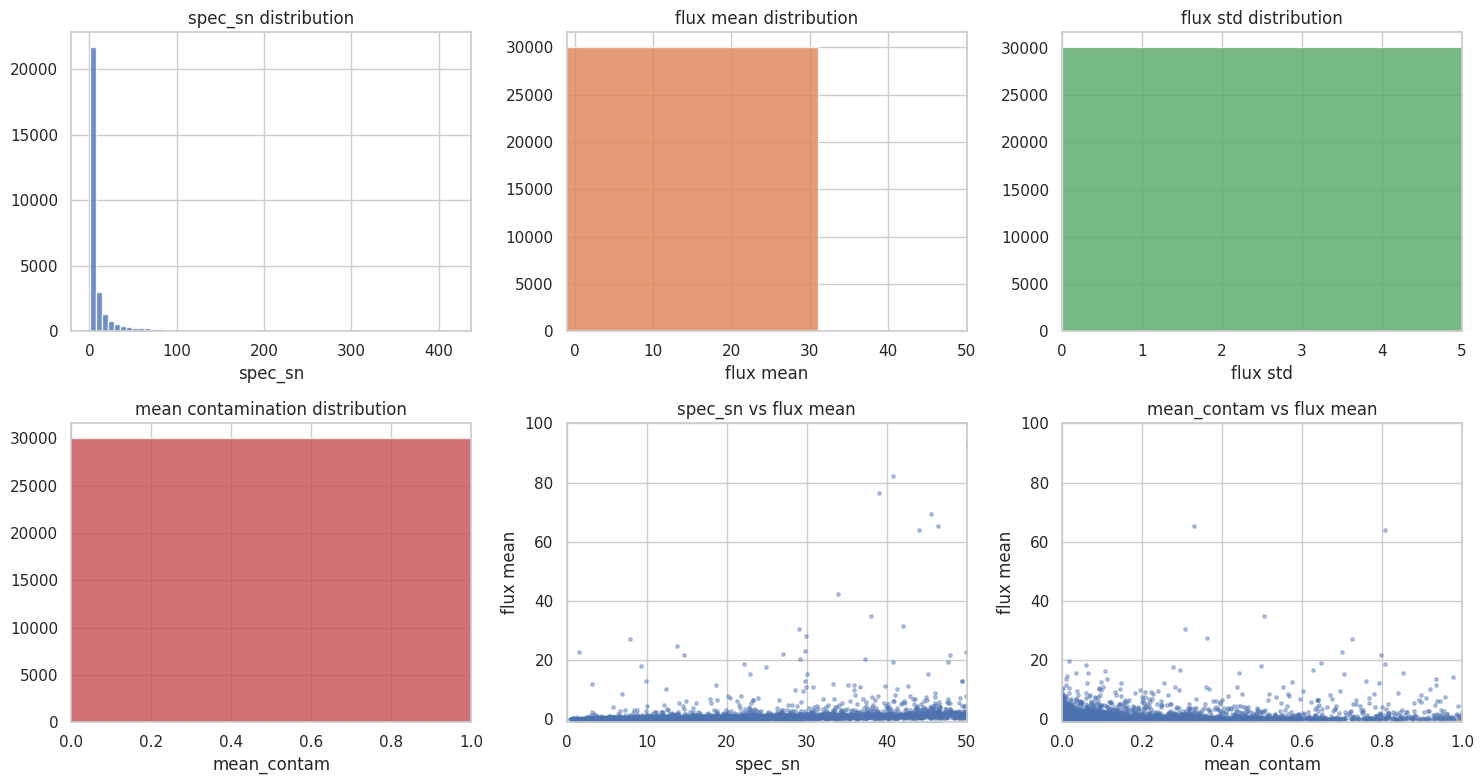

In [9]:
# Plot histograms and scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ax = axes[0,0]
ax.hist(valid_sn, bins=60, color='C0', alpha=0.8)
ax.set_title('spec_sn distribution')
ax.set_xlabel('spec_sn')

ax = axes[0,1]
ax.hist(flux_means, bins=80, color='C1', alpha=0.8)
ax.set_title('flux mean distribution')
ax.set_xlabel('flux mean')
ax.set_xlim(-1, 50)

ax = axes[0,2]
ax.hist(flux_stds, bins=80, color='C2', alpha=0.8)
ax.set_title('flux std distribution')
ax.set_xlabel('flux std')
ax.set_xlim(0, 5)

ax = axes[1,0]
ax.hist(mean_contam, bins=80, color='C3', alpha=0.8)
ax.set_title('mean contamination distribution')
ax.set_xlabel('mean_contam')
ax.set_xlim(0, 1)

ax = axes[1,1]
ax.scatter(spec_sn, flux_means, s=6, alpha=0.4)
ax.set_xlabel('spec_sn')
ax.set_ylabel('flux mean')
ax.set_title('spec_sn vs flux mean')
ax.set_xlim(0, 50)
ax.set_ylim(-1, 100)

ax = axes[1,2]
ax.scatter(mean_contam, flux_means, s=6, alpha=0.4)
ax.set_xlabel('mean_contam')
ax.set_ylabel('flux mean')
ax.set_title('mean_contam vs flux mean')
ax.set_xlim(0, 1)
ax.set_ylim(-1, 100)

plt.tight_layout()
plt.show()

## Recommendations

- Do not blindly drop all high-flux spectra: many are high S/N real sources. Instead:
  - Remove obviously contaminated spectra (e.g., `mean_contam > 0.5`) — this removes a small fraction (~3.6%) and many clear bad cases.
  - Use robust preprocessing (per-sample median/MAD or log-scaling) and robust loss (Huber) or sample weighting by `spec_sn` to reduce influence of bright outliers.
  - If you must restrict training distribution, use a documented combined filter such as `spec_sn > 2 and |flux_mean| < 5` (keeps ~57.7%).

- I can implement either the dataset-level `contam` threshold filter or add robust normalization to the model — tell me which you prefer and I will implement and run a small validation test.